## knock74追加実験

In [9]:
from knock70 import Word2Vectors
from knock72 import data_main
from knock72 import SingleLayerNN

import copy
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [10]:
def train_model(model, X_train, y_train, X_val, y_val, epochs, lr=0.01):

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    train_loss_list = []
    val_loss_list   = []

    best_val_loss = float('inf')
    best_state = None

    for epoch in range(epochs):

        model.train()
        y_pred     = model(X_train)
        train_loss = criterion(y_pred, y_train)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val)

        train_loss_list.append(train_loss.item())
        val_loss_list.append(val_loss.item())

        # ベスト判定は val のlossで行う
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_state    = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], " f"Train Loss: {train_loss.item():.4f}, " f"Val Loss  : {val_loss.item():.4f}")

    # val lossが最小だったときのモデルに戻す
    model.load_state_dict(best_state)

    return model, train_loss_list, val_loss_list

In [11]:
# データの準備
path_embedding = "GoogleNews-vectors-negative300.bin"
path_train     = "SST-2/train.tsv"
path_test      = "SST-2/dev.tsv"

word2id, id2word, E = Word2Vectors(path_embedding)
train_X, train_y    = data_main(path_train, word2id, E)
val_X, val_y        = data_main(path_test, word2id, E)

In [12]:
# モデルの構築
dim_input  = 300
dim_output = 1
model      = SingleLayerNN(dim_input, dim_output)

# モデルの学習
epochs = 10000
lr     = 0.01
model, train_loss_list, val_loss_list = train_model(model, train_X, train_y, val_X, val_y, epochs=epochs, lr=lr)

Epoch [100/10000], Train Loss: 0.6850, Val Loss  : 0.6892
Epoch [200/10000], Train Loss: 0.6783, Val Loss  : 0.6871
Epoch [300/10000], Train Loss: 0.6726, Val Loss  : 0.6851
Epoch [400/10000], Train Loss: 0.6676, Val Loss  : 0.6830
Epoch [500/10000], Train Loss: 0.6628, Val Loss  : 0.6808
Epoch [600/10000], Train Loss: 0.6583, Val Loss  : 0.6784
Epoch [700/10000], Train Loss: 0.6539, Val Loss  : 0.6760
Epoch [800/10000], Train Loss: 0.6497, Val Loss  : 0.6736
Epoch [900/10000], Train Loss: 0.6456, Val Loss  : 0.6711
Epoch [1000/10000], Train Loss: 0.6417, Val Loss  : 0.6687
Epoch [1100/10000], Train Loss: 0.6378, Val Loss  : 0.6664
Epoch [1200/10000], Train Loss: 0.6341, Val Loss  : 0.6640
Epoch [1300/10000], Train Loss: 0.6305, Val Loss  : 0.6618
Epoch [1400/10000], Train Loss: 0.6269, Val Loss  : 0.6595
Epoch [1500/10000], Train Loss: 0.6235, Val Loss  : 0.6574
Epoch [1600/10000], Train Loss: 0.6202, Val Loss  : 0.6552
Epoch [1700/10000], Train Loss: 0.6169, Val Loss  : 0.6532
Epoch 

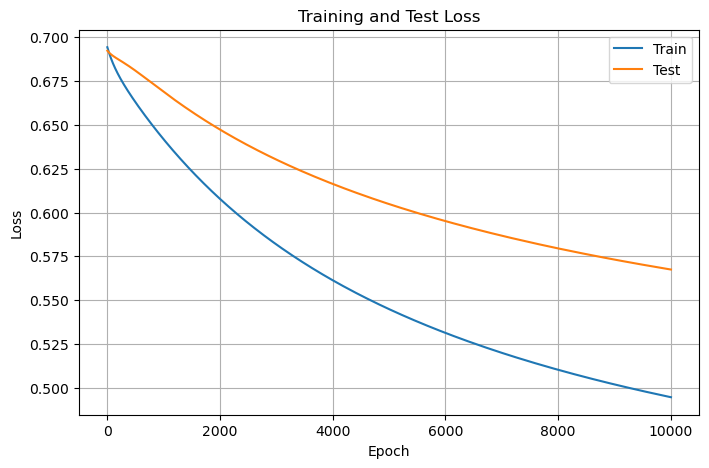

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_loss_list) + 1), train_loss_list, label="Train")
plt.plot(range(1, len(val_loss_list) + 1), val_loss_list, label="Test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(True)
plt.show()

### 一層のNNだと過学習は観測できない？？

In [14]:
def evaluate_model(model, X, y):

    criterion = nn.BCEWithLogitsLoss()
    model.eval()

    with torch.no_grad():
        logits = model(X)
        loss   = criterion(logits, y)

        # logit → 確率 → 0/1 のラベルに変換
        preds    = (torch.sigmoid(logits) >= 0.5).float()
        accuracy = (preds == y).float().mean()

    return loss.item(), accuracy.item()

In [20]:
# 評価
loss_train, accuracy_train = evaluate_model(model, train_X, train_y)
loss_test, accuracy_test   = evaluate_model(model, val_X, val_y)

print(f"Train Loss: {loss_train:.4f}, Train Accuracy: {accuracy_train:.4f}")
print(f"Val   Loss: {loss_test:.4f}, Val   Accuracy: {accuracy_test:.4f}")


Train Loss: 0.4948, Train Accuracy: 0.8036
Val   Loss: 0.5675, Val   Accuracy: 0.7603
